
=== Average Time (seconds) ===
data_size   20000    40000
threads                   
1          3.1248  13.3203
2          1.6280   6.9969
4          0.8296   3.6485
7          0.4957   2.2546
8          0.4545   1.9833
16         0.2734   1.0285
20         0.2589   0.8878
40         0.2039   0.8441

=== Speedup ===
data_size   20000   40000
threads                  
1           1.000   1.000
2           1.919   1.904
4           3.767   3.651
7           6.304   5.908
8           6.875   6.716
16         11.429  12.951
20         12.071  15.004
40         15.323  15.780


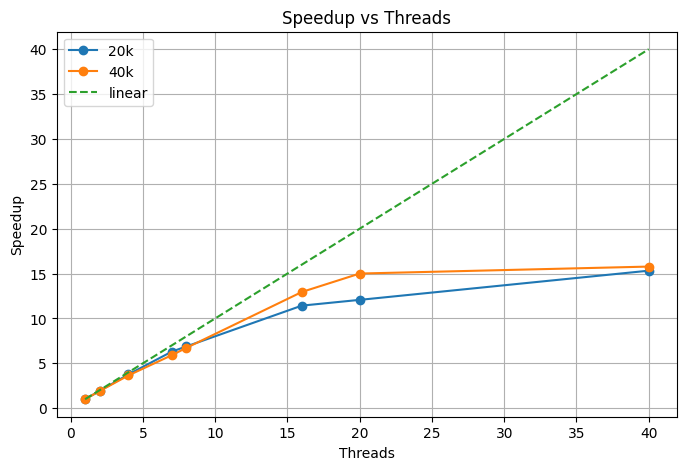

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('dgemv/dgemv_time.csv')
df.columns = df.columns.str.strip()

# 1. Очистка выбросов
q10 = df.groupby(['data_size', 'threads'])['time'].transform(lambda x: x.quantile(0.1))
q90 = df.groupby(['data_size', 'threads'])['time'].transform(lambda x: x.quantile(0.9))

df = df[(df['time'] >= q10) & (df['time'] <= q90)]

# 2. Среднее время
df_mean = df.groupby(['data_size', 'threads'])['time'].mean().reset_index()

# 3. Speedup
df_mean['speedup'] = df_mean.groupby('data_size')['time'].transform(lambda x: x.iloc[0] / x)

# 4. Таблицы

print("\n=== Average Time (seconds) ===")
time_table = df_mean.pivot(index='threads', columns='data_size', values='time')
print(time_table.round(4))

print("\n=== Speedup ===")
speedup_table = df_mean.pivot(index='threads', columns='data_size', values='speedup')
print(speedup_table.round(3))

# 5. График

df_20k = df_mean[df_mean['data_size'] == 20000]
df_40k = df_mean[df_mean['data_size'] == 40000]

threads = sorted(df_mean['threads'].unique())
ideal = threads

plt.figure(figsize=(8, 5))

plt.plot(df_20k['threads'], df_20k['speedup'], marker='o', label='20k')
plt.plot(df_40k['threads'], df_40k['speedup'], marker='o', label='40k')
plt.plot(threads, ideal, linestyle='--', label='linear')

plt.xlabel('Threads')
plt.ylabel('Speedup')
plt.title('Speedup vs Threads')
plt.legend()
plt.grid(True)

plt.show()


=== Average Time, Speedup, Efficiency ===
 threads   time  speedup  efficiency  rel_deviation
       1 0.4844   1.0000      1.0000         0.0000
       2 0.2433   1.9908      0.9954         0.0046
       4 0.1236   3.9198      0.9800         0.0200
       7 0.0711   6.8160      0.9737         0.0263
       8 0.0622   7.7905      0.9738         0.0262
      16 0.0312  15.5124      0.9695         0.0305
      20 0.0260  18.6242      0.9312         0.0688
      40 0.0197  24.5802      0.6145         0.3855


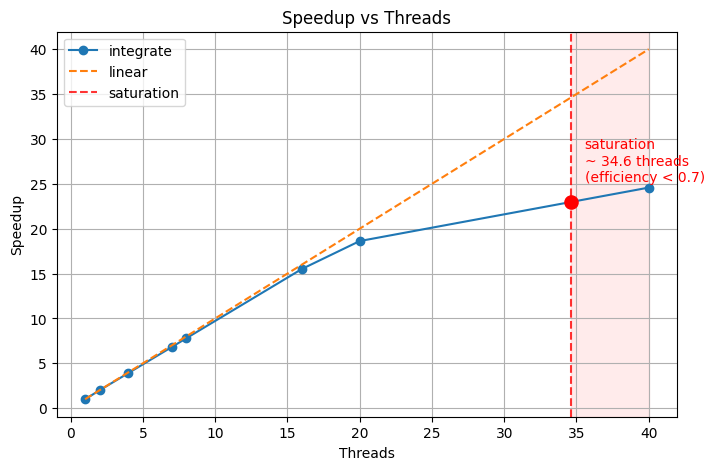


Estimated saturation point: 34.60 threads


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('integrate/integrate_time.csv')
df.columns = df.columns.str.strip()

# 1. Очистка выбросов
q10 = df.groupby('threads')['time'].transform(lambda x: x.quantile(0.1))
q90 = df.groupby('threads')['time'].transform(lambda x: x.quantile(0.9))

df = df[(df['time'] >= q10) & (df['time'] <= q90)]
df = df.groupby('threads', as_index=False)['time'].mean()

# 2. Метрики
df['speedup'] = df['time'].iloc[0] / df['time']
df['efficiency'] = df['speedup'] / df['threads']

# идеальная линейная линия
threads = df['threads'].to_numpy()
speedup = df['speedup'].to_numpy()
ideal = threads.astype(float)

# относительное отклонение от линейного ускорения:
# D_rel = (p - S(p)) / p = 1 - efficiency
df['rel_deviation'] = (threads - speedup) / threads

# 3. Вывод таблицы
print("\n=== Average Time, Speedup, Efficiency ===")
print(df[['threads', 'time', 'speedup', 'efficiency', 'rel_deviation']].round(4).to_string(index=False))

# 4. Оценка точки насыщения
# порог насыщения: efficiency < 0.7  <=>  rel_deviation > 0.3
threshold = 0.3

cross_idx = np.where(df['rel_deviation'].to_numpy() > threshold)[0]

p_sat = None
s_sat = None

if len(cross_idx) > 0:
    i2 = cross_idx[0]

    if i2 == 0:
        p_sat = threads[0]
        s_sat = speedup[0]
    else:
        i1 = i2 - 1

        p1, p2 = threads[i1], threads[i2]
        d1, d2 = df.loc[i1, 'rel_deviation'], df.loc[i2, 'rel_deviation']
        s1, s2 = speedup[i1], speedup[i2]

        if d2 != d1:
            alpha = (threshold - d1) / (d2 - d1)
            p_sat = p1 + alpha * (p2 - p1)
            s_sat = s1 + alpha * (s2 - s1)
        else:
            p_sat = p2
            s_sat = s2

# 5. График
plt.figure(figsize=(8, 5))

plt.plot(threads, speedup, marker='o', label='integrate')
plt.plot(threads, ideal, linestyle='--', label='linear')

if p_sat is not None and s_sat is not None:
    plt.axvline(p_sat, color='red', linestyle='--', alpha=0.8, label='saturation')
    plt.scatter(p_sat, s_sat, color='red', s=90, zorder=5)

    plt.annotate(
        f'saturation\n~ {p_sat:.1f} threads\n(efficiency < {1 - threshold})',
        xy=(p_sat, s_sat),
        xytext=(10, 15),
        textcoords='offset points',
        color='red'
    )

    plt.axvspan(p_sat, threads.max(), color='red', alpha=0.08)

plt.xlabel('Threads')
plt.ylabel('Speedup')
plt.title('Speedup vs Threads')
plt.legend()
plt.grid(True)

plt.show()

# 6. Итоговый вывод
if p_sat is not None:
    print(f'\nEstimated saturation point: {p_sat:.2f} threads')
else:
    print('\nSaturation point was not detected: rel_deviation never crossed the threshold.')

# SLAE
## Сравнение single omp section и multiple

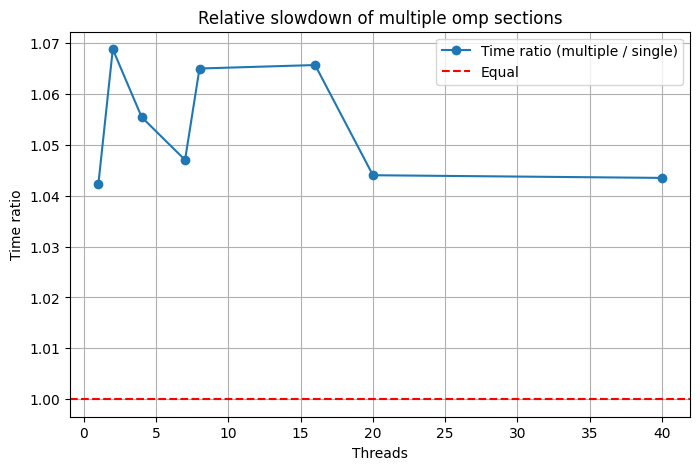

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def prepare_data(df):
    df.columns = df.columns.str.strip()

    q10 = df.groupby('threads')['time'].transform(lambda x: x.quantile(0.1))
    q90 = df.groupby('threads')['time'].transform(lambda x: x.quantile(0.9))

    df = df[(df['time'] >= q10) & (df['time'] <= q90)]
    df = df.groupby('threads')['time'].mean().reset_index()

    return df

df_single = pd.read_csv('slae/slae_single_block.csv')
df_multiple = pd.read_csv('slae/slae_multiple_blocks.csv')

df_single = prepare_data(df_single)
df_multiple = prepare_data(df_multiple)

# plot
df = df_single.merge(df_multiple, on='threads', suffixes=('_single', '_multi'))
df['ratio'] = df['time_multi'] / df['time_single']

plt.figure(figsize=(8, 5))
plt.plot(df['threads'], df['ratio'], marker='o', label='Time ratio (multiple / single)')
plt.axhline(1.0, linestyle='--', color='red', label='Equal')

plt.xlabel('Threads')
plt.ylabel('Time ratio')
plt.title('Relative slowdown of multiple omp sections')
plt.legend()
plt.grid(True)

plt.show()

Common serial baseline T1 = 30.080226 s


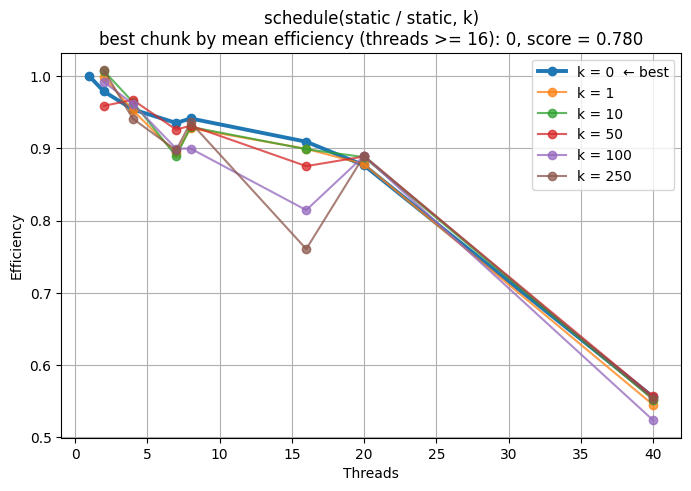

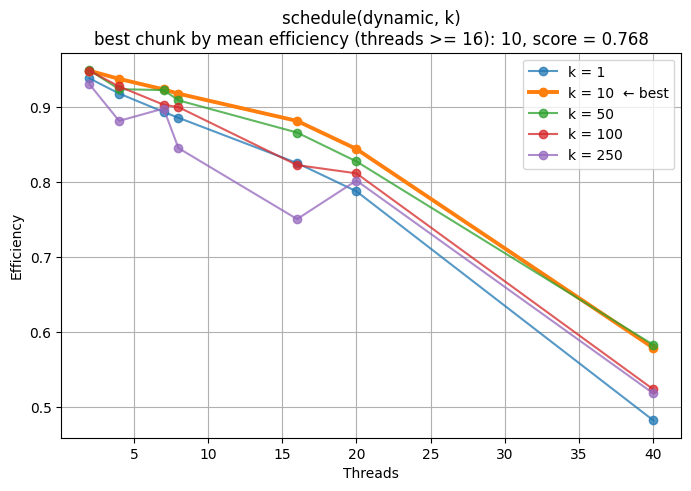

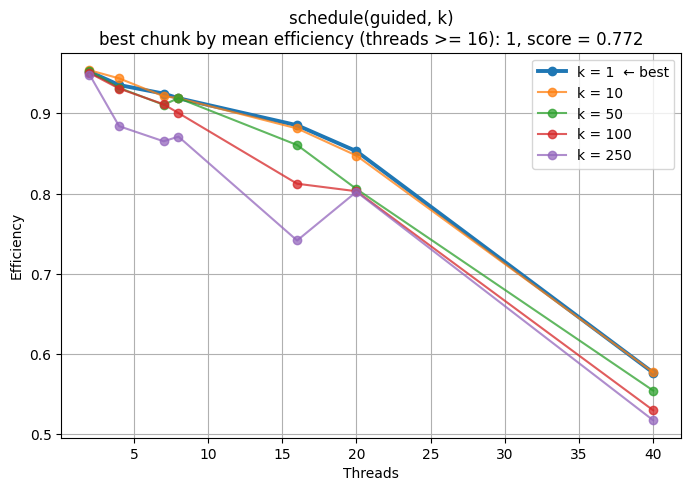


Best chunk for each scheduler (by mean efficiency on large thread counts):
 policy  best_chunk  mean_efficiency_score
 static           0               0.780376
 guided           1               0.771709
dynamic          10               0.768307

Best policy by scalability: static, best chunk = 0


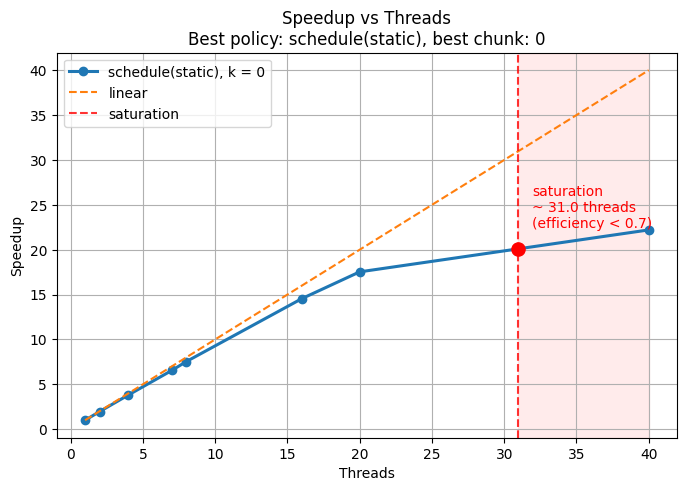

Estimated saturation point for schedule(static), k=0: 30.99 threads


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Подготовка данных

def prepare_data(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df.columns = df.columns.str.strip()

    q10 = df.groupby(['threads', 'chunks'])['time'].transform(lambda x: x.quantile(0.1))
    q90 = df.groupby(['threads', 'chunks'])['time'].transform(lambda x: x.quantile(0.9))

    df = df[(df['time'] >= q10) & (df['time'] <= q90)]
    df = df.groupby(['threads', 'chunks'], as_index=False)['time'].mean()
    df = df.sort_values(['chunks', 'threads']).reset_index(drop=True)

    return df


def add_common_baseline_metrics(df: pd.DataFrame, common_t1: float) -> pd.DataFrame:
    df = df.copy()
    df['t1_common'] = common_t1
    df['speedup'] = df['t1_common'] / df['time']
    df['efficiency'] = df['speedup'] / df['threads']
    return df


# 2. Выбор лучшего chunk

def choose_best_chunk_by_efficiency(df: pd.DataFrame, min_threads: int = 16) -> pd.DataFrame:
    candidates = df[df['threads'] >= min_threads].copy()

    summary = (
        candidates
        .groupby('chunks', as_index=False)
        .agg(
            mean_efficiency=('efficiency', 'mean'),
            min_time=('time', 'min')
        )
        .sort_values(['mean_efficiency', 'min_time'], ascending=[False, True])
        .reset_index(drop=True)
    )

    return summary


# 3. График efficiency для одного scheduler

def plot_efficiency_by_scheduler(
    df: pd.DataFrame,
    title: str,
    min_threads_for_choice: int = 16
):
    summary = choose_best_chunk_by_efficiency(df, min_threads=min_threads_for_choice)
    best_chunk = int(summary.iloc[0]['chunks'])
    best_score = float(summary.iloc[0]['mean_efficiency'])

    plt.figure(figsize=(8, 5))

    for chunk, group in df.groupby('chunks'):
        group = group.sort_values('threads')

        lw = 2.8 if chunk == best_chunk else 1.5
        alpha = 1.0 if chunk == best_chunk else 0.75

        label = f'k = {chunk}'
        if chunk == best_chunk:
            label += '  ← best'

        plt.plot(
            group['threads'],
            group['efficiency'],
            marker='o',
            linewidth=lw,
            alpha=alpha,
            label=label
        )

    plt.xlabel('Threads')
    plt.ylabel('Efficiency')
    plt.title(
        f'{title}\n'
        f'best chunk by mean efficiency (threads >= {min_threads_for_choice}): '
        f'{best_chunk}, score = {best_score:.3f}'
    )
    plt.grid(True)
    plt.legend()
    plt.show()

    return best_chunk, best_score


# 4. График ускорения лучшей policy + saturation

def plot_speedup_best_policy(
    df: pd.DataFrame,
    policy_name: str,
    best_chunk: int,
    sat_threshold: float = 0.3  # rel_deviation > 0.3 <=> efficiency < 0.7
):
    best_df = df[df['chunks'] == best_chunk].sort_values('threads').copy()

    threads = best_df['threads'].to_numpy()
    speedup = best_df['speedup'].to_numpy()
    ideal = threads.astype(float)

    # относительное отклонение от линейного ускорения
    best_df['rel_deviation'] = (threads - speedup) / threads

    cross_idx = np.where(best_df['rel_deviation'].to_numpy() > sat_threshold)[0]

    p_sat = None
    s_sat = None

    if len(cross_idx) > 0:
        i2 = cross_idx[0]

        if i2 == 0:
            p_sat = threads[0]
            s_sat = speedup[0]
        else:
            i1 = i2 - 1

            p1, p2 = threads[i1], threads[i2]
            d1, d2 = best_df.iloc[i1]['rel_deviation'], best_df.iloc[i2]['rel_deviation']
            s1, s2 = speedup[i1], speedup[i2]

            if d2 != d1:
                alpha = (sat_threshold - d1) / (d2 - d1)
                p_sat = p1 + alpha * (p2 - p1)
                s_sat = s1 + alpha * (s2 - s1)
            else:
                p_sat = p2
                s_sat = s2

    plt.figure(figsize=(8, 5))
    plt.plot(threads, speedup, marker='o', linewidth=2.2, label=f'{policy_name}, k = {best_chunk}')
    plt.plot(threads, ideal, linestyle='--', label='linear')

    if p_sat is not None and s_sat is not None:
        plt.axvline(p_sat, color='red', linestyle='--', alpha=0.8, label='saturation')
        plt.scatter(p_sat, s_sat, color='red', s=90, zorder=5)

        plt.annotate(
            f'saturation\n~ {p_sat:.1f} threads\n(efficiency < {1 - sat_threshold:.1f})',
            xy=(p_sat, s_sat),
            xytext=(10, 15),
            textcoords='offset points',
            color='red'
        )

        plt.axvspan(p_sat, threads.max(), color='red', alpha=0.08)

    plt.xlabel('Threads')
    plt.ylabel('Speedup')
    plt.title(f'Speedup vs Threads\nBest policy: {policy_name}, best chunk: {best_chunk}')
    plt.grid(True)
    plt.legend()
    plt.show()

    if p_sat is not None:
        print(f'Estimated saturation point for {policy_name}, k={best_chunk}: {p_sat:.2f} threads')
    else:
        print(f'Saturation point was not detected for {policy_name}, k={best_chunk}')


# 5. Загрузка данных

# static без chunk
df_static_base = pd.read_csv('slae/slae_single_block.csv')
df_static_base.columns = df_static_base.columns.str.strip()
df_static_base['chunks'] = 0

# static(k)
df_static_k = pd.read_csv('slae/slae_static_k.csv')
df_static_k.columns = df_static_k.columns.str.strip()

# объединяем обычный static и static(k)
df_static = pd.concat([df_static_base, df_static_k], ignore_index=True)

# dynamic / guided
df_dynamic = pd.read_csv('slae/slae_dynamic.csv')
df_dynamic.columns = df_dynamic.columns.str.strip()

df_guided = pd.read_csv('slae/slae_guided.csv')
df_guided.columns = df_guided.columns.str.strip()

# подготовка
df_static = prepare_data(df_static)
df_dynamic = prepare_data(df_dynamic)
df_guided = prepare_data(df_guided)

# 6. Общий baseline T1 из static без chunk
static_serial_rows = df_static[(df_static['chunks'] == 0) & (df_static['threads'] == 1)]
if static_serial_rows.empty:
    raise ValueError('В df_static нет baseline для обычного static при threads=1')

common_t1 = float(static_serial_rows['time'].iloc[0])
print(f'Common serial baseline T1 = {common_t1:.6f} s')

# добавляем метрики относительно общего baseline
df_static = add_common_baseline_metrics(df_static, common_t1)
df_dynamic = add_common_baseline_metrics(df_dynamic, common_t1)
df_guided = add_common_baseline_metrics(df_guided, common_t1)

# 7. Три графика efficiency
best_static_chunk, best_static_score = plot_efficiency_by_scheduler(
    df_static,
    'schedule(static / static, k)',
    min_threads_for_choice=16
)

best_dynamic_chunk, best_dynamic_score = plot_efficiency_by_scheduler(
    df_dynamic,
    'schedule(dynamic, k)',
    min_threads_for_choice=16
)

best_guided_chunk, best_guided_score = plot_efficiency_by_scheduler(
    df_guided,
    'schedule(guided, k)',
    min_threads_for_choice=16
)

# 8. Выбор лучшей policy
policy_summary = pd.DataFrame({
    'policy': ['static', 'dynamic', 'guided'],
    'best_chunk': [best_static_chunk, best_dynamic_chunk, best_guided_chunk],
    'mean_efficiency_score': [best_static_score, best_dynamic_score, best_guided_score]
}).sort_values('mean_efficiency_score', ascending=False).reset_index(drop=True)

print('\nBest chunk for each scheduler (by mean efficiency on large thread counts):')
print(policy_summary.to_string(index=False))

best_policy = policy_summary.iloc[0]['policy']
best_chunk = int(policy_summary.iloc[0]['best_chunk'])

print(f'\nBest policy by scalability: {best_policy}, best chunk = {best_chunk}')

# 9. Четвёртый график: speedup лучшей policy + saturation
if best_policy == 'static':
    plot_speedup_best_policy(df_static, 'schedule(static)', best_chunk, sat_threshold=0.3)
elif best_policy == 'dynamic':
    plot_speedup_best_policy(df_dynamic, 'schedule(dynamic)', best_chunk, sat_threshold=0.3)
else:
    plot_speedup_best_policy(df_guided, 'schedule(guided)', best_chunk, sat_threshold=0.3)